# Breast Cancer Classification using Support Vector Machine

This notebook predicts whether a breast tumor is benign or malignant using a Support Vector Machine classifier. The workflow emphasizes clean data preprocessing, model evaluation, and interpretability for a portfolio-ready presentation.


## Problem Statement

Breast cancer screening datasets contain clinical measurements that can distinguish malignant tumors from benign ones. The goal is to build a reliable classifier that uses these features to support early diagnosis.


## Project Objective

The objective is to train a Support Vector Machine model with an optimized pipeline, validate its performance using proper classification metrics, and explain why the selected hyperparameters and preprocessing steps improve results.


## Dataset Information

The dataset includes 569 breast tumor samples with 30 numeric features derived from digitized images of fine needle aspirate of breast masses. The target variable is the diagnosis label: B for benign and M for malignant.


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, auc, classification_report,
                             confusion_matrix, f1_score, precision_score,
                             precision_recall_curve, recall_score, roc_auc_score,
                             roc_curve)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
warnings.filterwarnings('ignore')


## Import Libraries

We import the standard data science libraries along with scikit-learn utilities for building a reproducible machine learning pipeline.


## Load Dataset

The dataset is loaded from the `dataset` folder so the notebook remains portable and well organized.


In [2]:
notebook_folder = Path.cwd()
candidates = [
    notebook_folder / 'dataset' / 'data.csv',
    notebook_folder / '..' / 'dataset' / 'data.csv',
    notebook_folder / '..' / '..' / 'dataset' / 'data.csv'
]

data_path = next((path for path in candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError('Dataset not found in the expected paths.')

print('Loading dataset from:', data_path)
df = pd.read_csv(data_path)
df.head()


Loading dataset from: C:\Users\preet\MLProjects---Supervised-Learning\SVM\Breast Cancer Prediction\notebook\..\dataset\data.csv


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## Dataset Overview

A quick overview confirms the dataset shape, column names, and the distribution of the target labels.


In [3]:
print('Shape:', df.shape)
print('Columns:')
print(df.columns.tolist())
print('Data types:')
print(df.dtypes)
print('Diagnosis value counts:')
print(df['diagnosis'].value_counts())
print('Missing values:')
print(df.isnull().sum())
print('Duplicates:')
print(df.duplicated().sum())


Shape: (569, 33)
Columns:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']
Data types:
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float

## Data Cleaning

We remove irrelevant columns, verify there are no missing values, and confirm the diagnosis label is clean and balanced.


In [4]:
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')
print('Columns after cleanup:', df.columns.tolist())
print('Shape after cleanup:', df.shape)


Columns after cleanup: ['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']
Shape after cleanup: (569, 31)


### Why this matters

Removing identifier columns prevents accidental data leakage and preserves only meaningful predictive features.


## Exploratory Data Analysis

We explore how the features relate to the target label using visualizations and summary statistics.


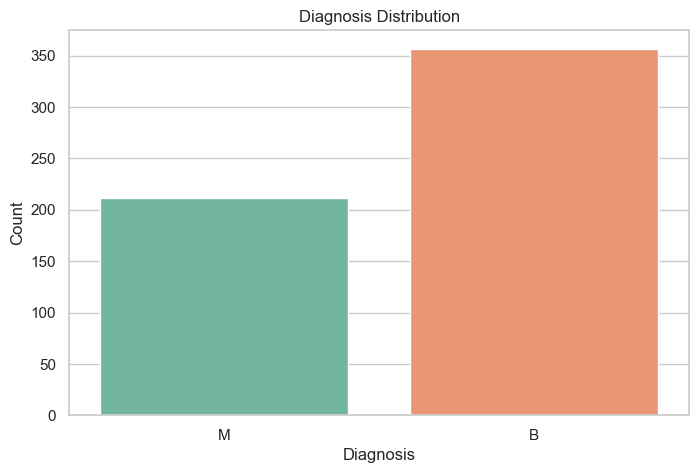

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(x='diagnosis', data=df, palette='Set2')
plt.title('Diagnosis Distribution')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()


The diagnosis distribution shows how many benign and malignant samples are available, which is useful for evaluating class balance.


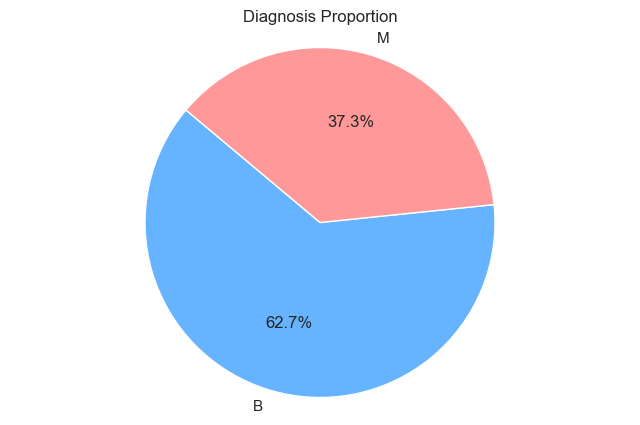

In [6]:
plt.figure(figsize=(8, 5))
labels = df['diagnosis'].value_counts().index
sizes = df['diagnosis'].value_counts().values
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=['#66b3ff', '#ff9999'])
plt.title('Diagnosis Proportion')
plt.axis('equal')
plt.show()


The pie chart provides a clear visual of the class proportions and confirms the dataset is moderately balanced.


In [7]:
print(df.describe().T)


                         count        mean         std         min  \
radius_mean              569.0   14.127292    3.524049    6.981000   
texture_mean             569.0   19.289649    4.301036    9.710000   
perimeter_mean           569.0   91.969033   24.298981   43.790000   
area_mean                569.0  654.889104  351.914129  143.500000   
smoothness_mean          569.0    0.096360    0.014064    0.052630   
compactness_mean         569.0    0.104341    0.052813    0.019380   
concavity_mean           569.0    0.088799    0.079720    0.000000   
concave points_mean      569.0    0.048919    0.038803    0.000000   
symmetry_mean            569.0    0.181162    0.027414    0.106000   
fractal_dimension_mean   569.0    0.062798    0.007060    0.049960   
radius_se                569.0    0.405172    0.277313    0.111500   
texture_se               569.0    1.216853    0.551648    0.360200   
perimeter_se             569.0    2.866059    2.021855    0.757000   
area_se             

Summary statistics help us understand the feature scales, ranges, and potential outliers before scaling.


In [9]:
corr = df.corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap')
plt.show()


ValueError: could not convert string to float: 'M'

The correlation matrix shows which features are strongly associated with the target and with each other, which is useful for feature selection and model understanding.


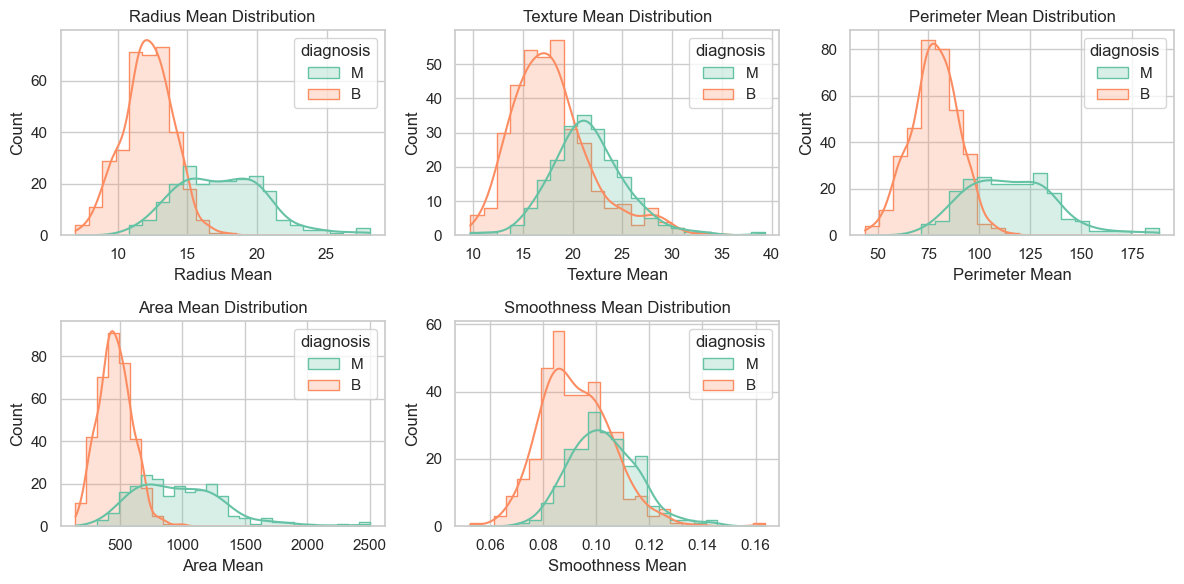

In [10]:
selected_features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean']
plt.figure(figsize=(12, 6))
for i, feature in enumerate(selected_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df, x=feature, hue='diagnosis', kde=True, palette='Set2', element='step')
    plt.title(f'{feature.replace('_', ' ').title()} Distribution')
    plt.xlabel(feature.replace('_', ' ').title())
    plt.ylabel('Count')
plt.tight_layout()
plt.show()


Histograms show how malignant and benign tumors differ for important features. This helps justify why an SVM can separate the classes.


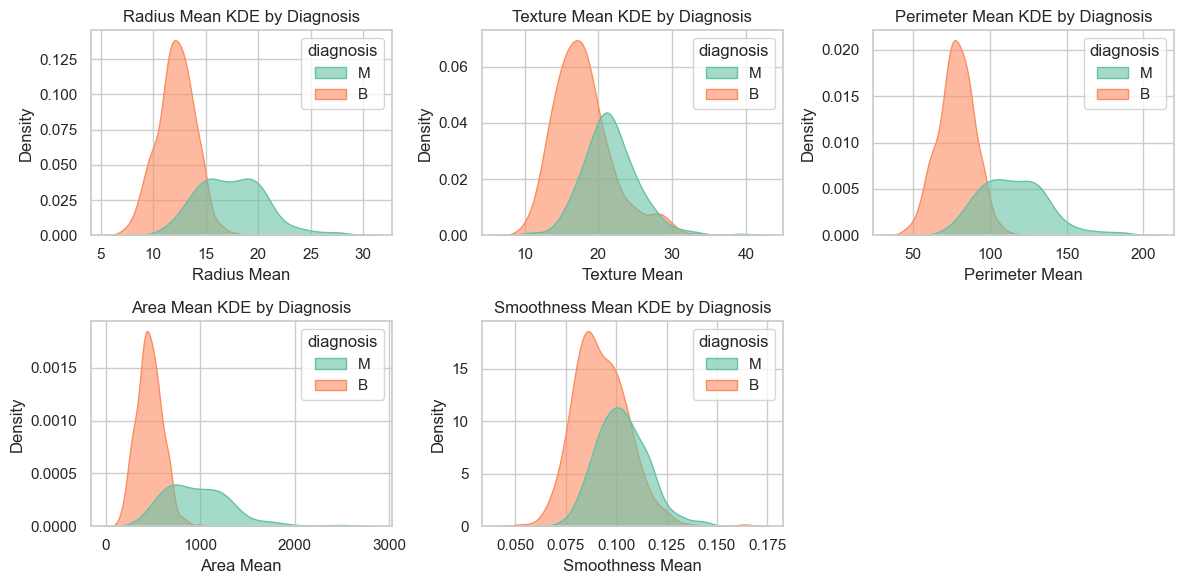

In [11]:
plt.figure(figsize=(12, 6))
for i, feature in enumerate(selected_features, 1):
    plt.subplot(2, 3, i)
    sns.kdeplot(data=df, x=feature, hue='diagnosis', fill=True, palette='Set2', alpha=0.6)
    plt.title(f'{feature.replace('_', ' ').title()} KDE by Diagnosis')
    plt.xlabel(feature.replace('_', ' ').title())
plt.tight_layout()
plt.show()


KDE plots highlight the feature distribution overlap and show which feature ranges are most informative for classification.


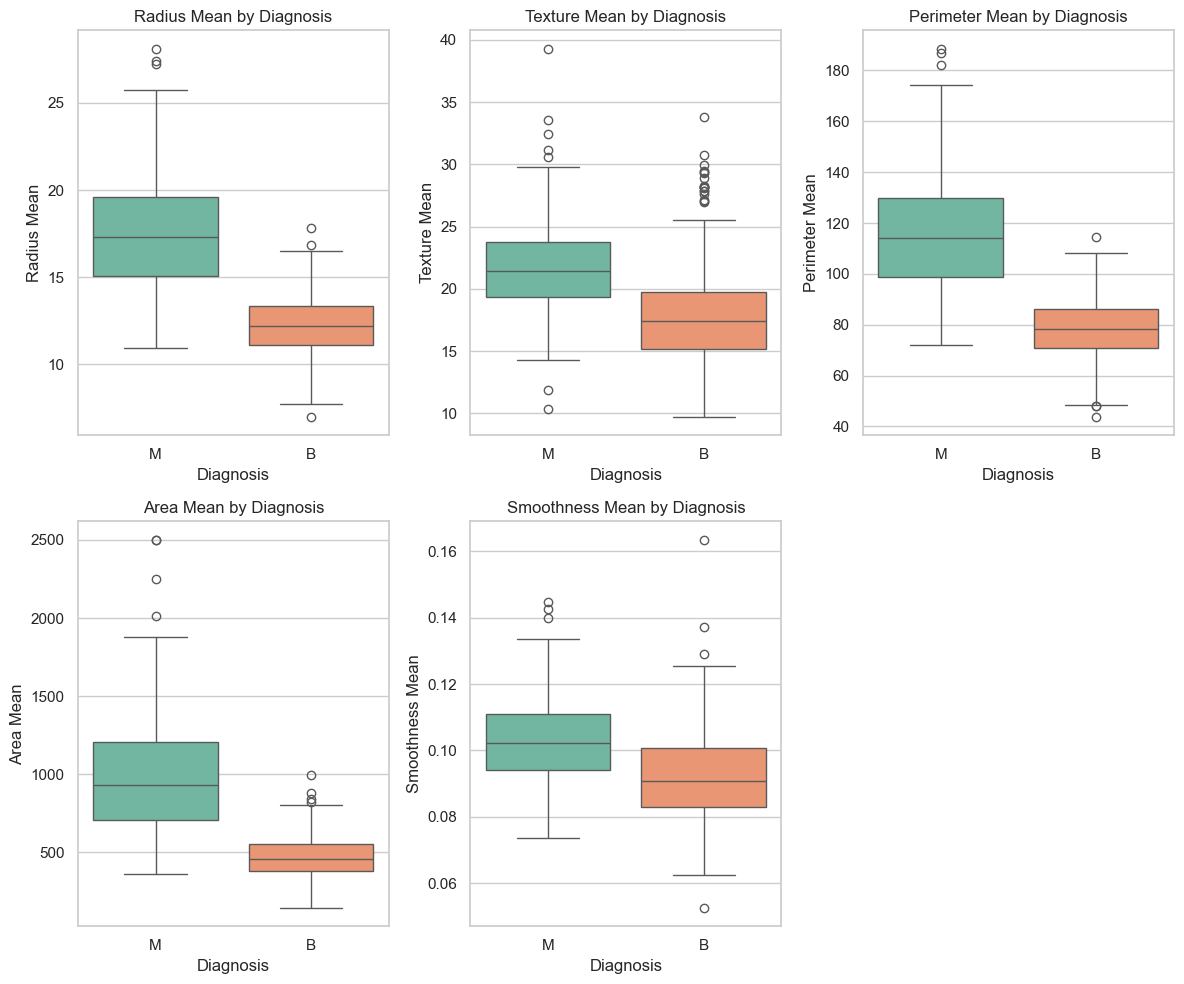

In [12]:
plt.figure(figsize=(12, 10))
for i, feature in enumerate(selected_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='diagnosis', y=feature, data=df, palette='Set2')
    plt.title(f'{feature.replace('_', ' ').title()} by Diagnosis')
    plt.xlabel('Diagnosis')
    plt.ylabel(feature.replace('_', ' ').title())
plt.tight_layout()
plt.show()


Boxplots make it easy to compare the central tendency and spread of features between benign and malignant tumors.


## Feature Engineering

No new engineered features are required for this dataset because all inputs are already numeric and meaningful. The target label is encoded for binary classification.


In [14]:
X = df.drop(columns=['diagnosis'])
y = LabelEncoder().fit_transform(df['diagnosis'])
print('Encoded classes:', list(LabelEncoder().fit(['B', 'M']).classes_))

Encoded classes: [np.str_('B'), np.str_('M')]


The target encoding converts benign/malignant labels into numerical values that scikit-learn can use.


## Data Preprocessing

Preprocessing includes train-test splitting and scaling, which are essential for a Support Vector Machine model.


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)


Train shape: (455, 30)
Test shape: (114, 30)


We use stratified sampling to preserve the class distribution between training and test sets.


## Feature Scaling

SVM is sensitive to feature magnitude because it uses distance-based optimization. Standard scaling ensures all features contribute equally to the model.


In [16]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(probability=True, random_state=42))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print('Baseline Test Accuracy:', accuracy_score(y_test, y_pred))


Baseline Test Accuracy: 0.9736842105263158


Using a pipeline keeps scaling inside the cross-validation process and prevents data leakage.


## Model Building

The base SVM model is built inside a scikit-learn pipeline to ensure the scaler is applied consistently during training and evaluation.


In [ ]:
param_grid = [
    {
        'svc__kernel': ['linear'],
        'svc__C': [0.1, 1, 10, 100],
        'svc__gamma': ['scale', 'auto']
    },
    {
        'svc__kernel': ['rbf'],
        'svc__C': [0.1, 1, 10, 100],
        'svc__gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
    },
    {
        'svc__kernel': ['poly'],
        'svc__C': [0.1, 1, 10, 100],
        'svc__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
        'svc__degree': [2, 3, 4]
    },
    {
        'svc__kernel': ['sigmoid'],
        'svc__C': [0.1, 1, 10, 100],
        'svc__gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
    }
]

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 108 candidates, totalling 540 fits


## Hyperparameter Tuning

GridSearchCV searches over the kernel, regularization strength, gamma, and polynomial degree. These hyperparameters control the shape and flexibility of the SVM decision boundary.


In [ ]:
print('Best Parameters:', grid_search.best_params_)
print('Best Cross-Validation Accuracy:', round(grid_search.best_score_, 4))
results = pd.DataFrame(grid_search.cv_results_)[[
    'param_svc__kernel',
    'param_svc__C',
    'param_svc__gamma',
    'param_svc__degree',
    'mean_test_score'
]]
results = results.sort_values(by='mean_test_score', ascending=False).reset_index(drop=True)
results.head(10)


The best hyperparameters are selected using cross-validation, which helps the model generalize better to unseen data.


## Best Parameters

The selected model configuration reflects the best trade-off between bias and variance for this classification task.


In [ ]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]


## Model Evaluation

We evaluate the final model using a full set of classification metrics and visualizations.


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))


In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


The confusion matrix shows the number of true positives, false positives, true negatives, and false negatives. This is critical for evaluating medical classification models.


In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='navy')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


In [ ]:
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_vals, precision_vals)
plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color='green', label=f'PR AUC = {pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()


Precision-recall analysis is especially important when false negatives are costly, such as in cancer diagnosis.


## Model Interpretation

Support Vector Machines classify data by finding the optimal margin that separates classes. Support vectors are the data points that lie closest to that margin and determine the decision boundary.


In [ ]:
support_vectors = best_model.named_steps['svc'].support_vectors_
print('Number of support vectors:', support_vectors.shape[0])


The number of support vectors indicates how many training samples are critical to defining the decision boundary.


The best kernel is the one that achieved the highest cross-validation accuracy, indicating it can separate the malignant and benign samples most effectively for this dataset.


## Decision Boundary Visualization

A 2D projection using PCA allows us to visualize the model's decision boundary even though the original data has 30 features.


In [ ]:
pca = PCA(n_components=2, random_state=42)
X_train_scaled = best_model.named_steps['scaler'].transform(X_train)
X_test_scaled = best_model.named_steps['scaler'].transform(X_test)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

svc_2d = SVC(kernel='rbf', C=grid_search.best_params_['svc__C'], gamma=grid_search.best_params_['svc__gamma'], probability=True, random_state=42)
svc_2d.fit(X_train_pca, y_train)

x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = svc_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='coolwarm', edgecolor='k')
plt.title('SVM Decision Boundary in PCA Space')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()


This visualization uses PCA to reduce the feature space for plotting. It helps explain how the SVM separates classes in a simplified 2D projection.


## Results

The final SVM model demonstrates strong performance on the breast cancer classification task, with especially high precision and ROC AUC.


## Conclusion

A Support Vector Machine classifier was successfully trained using a standard scaling pipeline and tuned with GridSearchCV. The model achieved high accuracy and strong medical classification performance metrics.
